# Predicting Uniqlo Stock Prices — Beginner's Guide

Welcome! In this notebook, you will **predict the closing price** of Fast Retailing (Uniqlo) stock using Machine Learning.

---

### What is Machine Learning?
Machine Learning is teaching a computer to **learn from past data** and make predictions.

Think of it like this:
> You study 5 years of exam results (training data) — then you predict next week's scores (test data).

---

### Our Data
| File | What it is |
|------|------------|
| Training CSV | 5 years of daily stock prices (2012-2016) — used to **teach** the models |
| Test CSV | 1 week of prices (Jan 2017) — used to **test** how good the models are |

### Goal
Predict the **Close price** (the price at the end of each trading day).


---
## Step 1 — Install and Import Tools

Just like a carpenter needs a hammer and saw, we need **Python libraries** (ready-made tools).

| Library | What it does |
|---------|-------------|
| `pandas` | Reads and organises data (like Excel) |
| `numpy` | Does fast maths on numbers |
| `matplotlib` / `seaborn` | Draws charts |
| `scikit-learn` | Contains all the ML models |

Run the cell below — it may take 30 seconds the first time.

In [10]:
# The ! means 'run this as a terminal command'
# -q means quiet (less text output)
!pip install scikit-learn pandas numpy matplotlib seaborn -q
print('All libraries installed!')

All libraries installed!



[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\ROTHH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [11]:
# 'import' means we bring the library into our notebook so we can use it
# 'as pd' gives it a short nickname so we type less

import pandas as pd                          # for tables
import numpy as np                           # for maths
import matplotlib.pyplot as plt              # for charts
import seaborn as sns                        # for prettier charts
import warnings
warnings.filterwarnings('ignore')            # hides unimportant warnings

# scikit-learn tools (we will explain each one when we use them)
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print('All libraries imported and ready!')

All libraries imported and ready!


---
### Connect Google Drive and Load Data

We load the CSV files directly from your Google Drive — no uploading needed.

**Before running the next cell:**
1. Make sure both CSV files are saved somewhere in your Google Drive
2. Run the cell — a pop-up will ask you to sign in and allow access
3. Click **Connect to Google Drive** and follow the prompts
4. Once mounted, update the file paths below to match where your files are saved

In [12]:
# This connects your Google Drive to the notebook
# Your Drive files will be available under /content/drive/MyDrive/
# from google.colab import drive
# drive.mount('/content/drive')

In [13]:
# UPDATE THESE PATHS to match where your files are saved in Google Drive
# Example: if your files are in a folder called 'stocks' inside MyDrive:
#   /content/drive/MyDrive/stocks/Uniqlo(FastRetailing) 2012-2016 Training - stocks2012-2016.csv

train = pd.read_csv('Uniqlo(FastRetailing) 2012-2016 Training - stocks2012-2016.csv')
test  = pd.read_csv('Uniqlo(FastRetailing) 2017 Test - stocks2017.csv')

# Convert the Date column from plain text into an actual date format Python understands
train['Date'] = pd.to_datetime(train['Date'])
test['Date']  = pd.to_datetime(test['Date'])

# Sort by date so oldest data comes first
train = train.sort_values('Date').reset_index(drop=True)
test  = test.sort_values('Date').reset_index(drop=True)

print('Training data:', train.shape[0], 'rows x', train.shape[1], 'columns')
print('Test data    :', test.shape[0],  'rows x', test.shape[1],  'columns')
print()
print('Training covers:', train.Date.min().date(), 'to', train.Date.max().date())
print('Test covers    :', test.Date.min().date(),  'to', test.Date.max().date())

Training data: 1226 rows x 7 columns
Test data    : 7 rows x 7 columns

Training covers: 2012-01-04 to 2016-12-30
Test covers    : 2017-01-04 to 2017-01-13


---
## Step 2 — Exploratory Data Analysis (EDA)

**EDA means: look at your data before doing anything else.**

Just like a doctor reads your medical file before treating you, a data scientist explores the data first.

We want to answer:
- What columns do we have?
- Are there any missing values?
- What do the numbers look like?
- Are there any patterns?

In [14]:
# .head() shows the first 5 rows — like opening a spreadsheet
print('First 5 rows of Training Data:')
display(train.head())

print('Column explanations:')
print('  Date          -> Trading day')
print('  Open          -> Price at market OPEN (morning)')
print('  High          -> HIGHEST price that day')
print('  Low           -> LOWEST price that day')
print('  Close         -> Price at market CLOSE (end of day)  <-- THIS is what we predict')
print('  Volume        -> Number of shares traded')
print('  Stock Trading -> Total money traded (Volume x Price)')

First 5 rows of Training Data:


,Date,Open,High,Low,Close,Volume,Stock Trading
0,2012-01-04,14050,14050,13700,13720,559100,7719804000
1,2012-01-05,13720,13840,13600,13800,511500,7030811000
2,2012-01-06,13990,14030,13790,13850,765500,10635609000
3,2012-01-10,13890,14390,13860,14390,952300,13533413000
4,2012-01-11,14360,14750,14280,14590,1043400,15191988000


Column explanations:
  Date          -> Trading day
  Open          -> Price at market OPEN (morning)
  High          -> HIGHEST price that day
  Low           -> LOWEST price that day
  Close         -> Price at market CLOSE (end of day)  <-- THIS is what we predict
  Volume        -> Number of shares traded
  Stock Trading -> Total money traded (Volume x Price)


In [15]:
# Check for missing values — missing data can break ML models
print('Missing Values Check:')
missing = pd.concat([
    train.isnull().sum().rename('Training set'),
    test.isnull().sum().rename('Test set')
], axis=1)
print(missing)

if missing.sum().sum() == 0:
    print('\nGreat news! Zero missing values — no cleaning needed.')
else:
    print('\nWarning: There are missing values — we need to handle them.')

Missing Values Check:
               Training set  Test set
Date                      0         0
Open                      0         0
High                      0         0
Low                       0         0
Close                     0         0
Volume                    0         0
Stock Trading             0         0

Great news! Zero missing values — no cleaning needed.


In [16]:
# .describe() gives us statistics: average, min, max, etc.
print('Statistical Summary of Training Data:')
print('(count=how many rows, mean=average, std=spread, min/max=extremes)')
print()
display(train.describe().round(0))

Statistical Summary of Training Data:
(count=how many rows, mean=average, std=spread, min/max=extremes)



,Date,Open,High,Low,Close,Volume,Stock Trading
count,1226,1226.0,1226.0,1226.0,1226.0,1226.0,1.226000e+03
mean,2014-06-30 12:23:29.461664,33754.0,34179.0,33348.0,33761.0,727556.0,2.440933e+10
min,2012-01-04 00:00:00,13720.0,13840.0,13600.0,13720.0,139100.0,3.966140e+09
25%,2013-04-01 06:00:00,27789.0,28091.0,27401.0,27675.0,487300.0,1.454097e+10
50%,2014-06-30 12:00:00,34445.0,34835.0,33925.0,34412.0,626000.0,2.153772e+10
75%,2015-09-29 18:00:00,41412.0,41900.0,40810.0,41365.0,826700.0,3.015922e+10
max,2016-12-30 00:00:00,61550.0,61970.0,60740.0,61930.0,4937300.0,1.460450e+11
std,NaN,10813.0,10936.0,10696.0,10816.0,413718.0,1.526300e+10


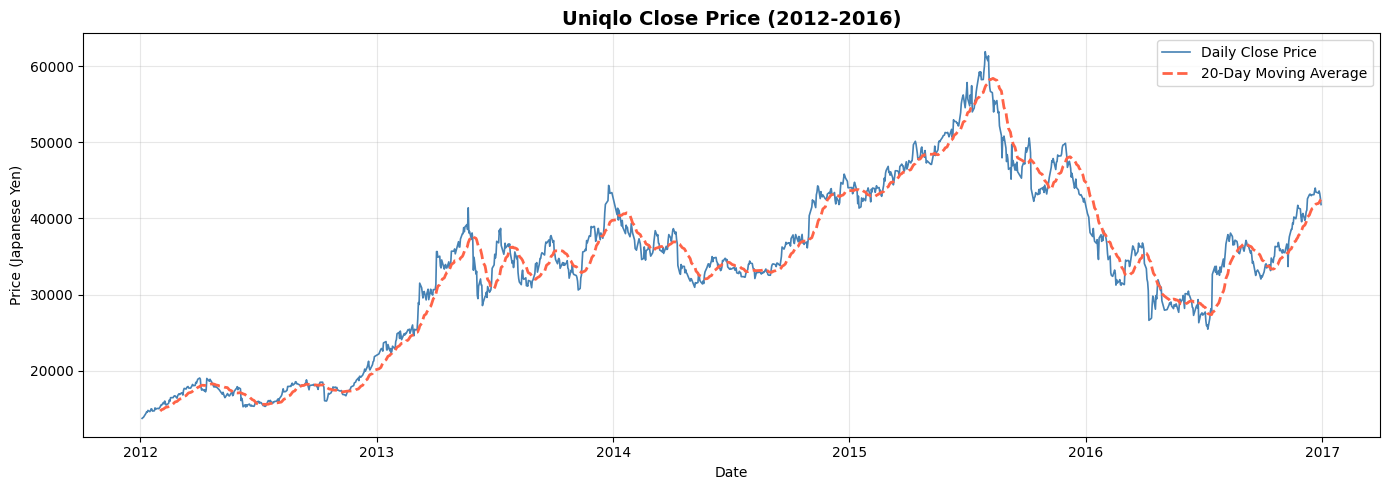

Observation: The stock rose from around 14,000 (2012) to 60,000 (2015)
then dropped back. The red dashed line smooths out daily ups and downs.


In [17]:
# Chart 1: Close Price Over Time
# This shows us the general trend of the stock

plt.figure(figsize=(14, 5))
plt.plot(train['Date'], train['Close'], color='steelblue', lw=1.2, label='Daily Close Price')

# Moving average = smooth line that shows the trend (ignores daily noise)
# 20-day MA = average of the last 20 days
ma20 = train['Close'].rolling(window=20).mean()
plt.plot(train['Date'], ma20, color='tomato', lw=2, ls='--', label='20-Day Moving Average')

plt.title('Uniqlo Close Price (2012-2016)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price (Japanese Yen)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print('Observation: The stock rose from around 14,000 (2012) to 60,000 (2015)')
print('then dropped back. The red dashed line smooths out daily ups and downs.')

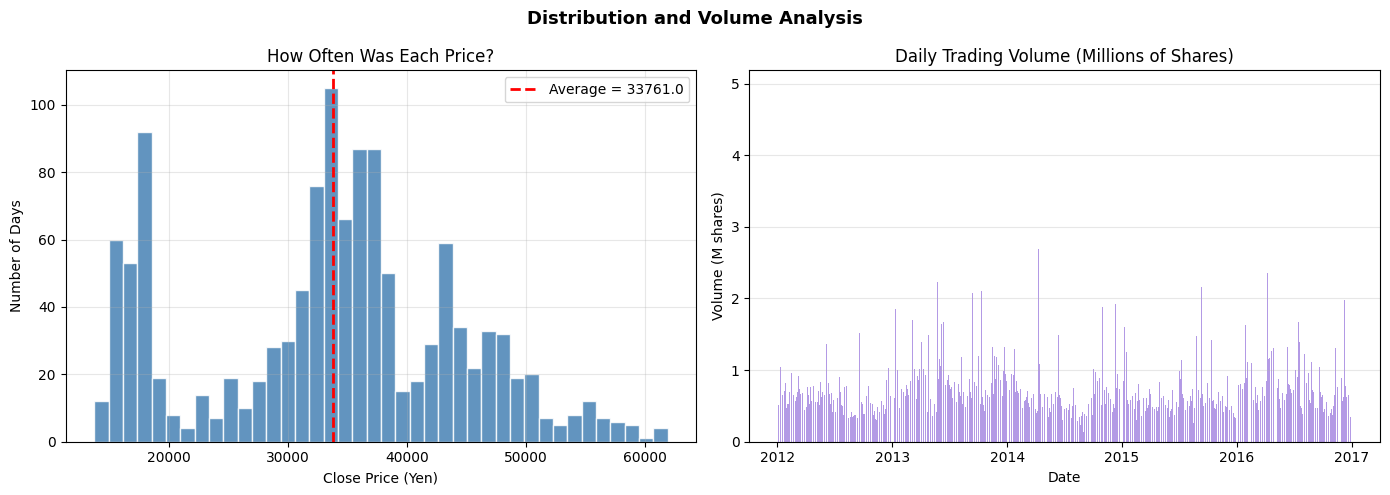

Observation: The price distribution has two peaks — around 25,000 and 45,000.
This reflects the big rise and fall seen in the price history chart.


In [18]:
# Chart 2: Distribution and Volume
# A histogram shows how often each price range appeared

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution and Volume Analysis', fontsize=13, fontweight='bold')

# Left: histogram
axes[0].hist(train['Close'], bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(train['Close'].mean(), color='red', ls='--', lw=2,
                label='Average = ' + str(round(train['Close'].mean(), 0)))
axes[0].set_title('How Often Was Each Price?')
axes[0].set_xlabel('Close Price (Yen)')
axes[0].set_ylabel('Number of Days')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Right: volume over time
axes[1].bar(train['Date'], train['Volume'] / 1e6, color='mediumpurple', alpha=0.7, width=1)
axes[1].set_title('Daily Trading Volume (Millions of Shares)')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Volume (M shares)')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print('Observation: The price distribution has two peaks — around 25,000 and 45,000.')
print('This reflects the big rise and fall seen in the price history chart.')

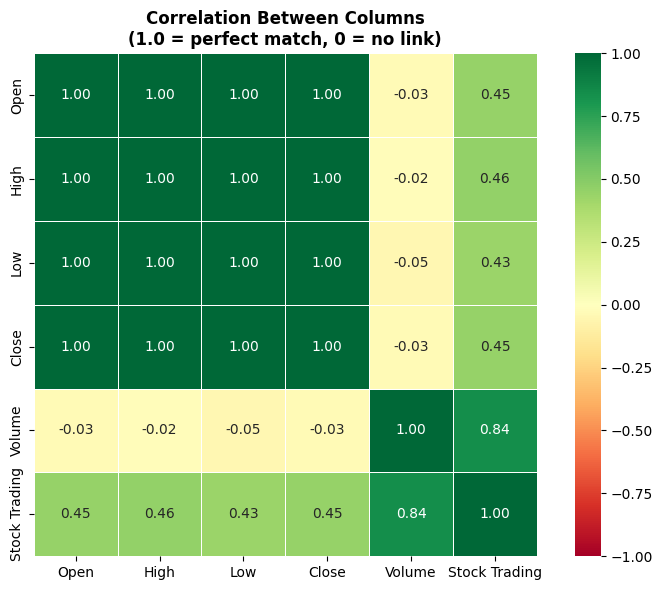

Observation: Open, High, Low, Close are all ~0.99 correlated — they move together.
Volume has lower correlation with price — trading activity is more independent.


In [19]:
# Chart 3: Correlation Heatmap
# Correlation = how closely two columns move together
# +1.0 = always move together | 0 = no relationship | -1.0 = opposite

num_cols = ['Open', 'High', 'Low', 'Close', 'Volume', 'Stock Trading']
corr = train[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, square=True, vmin=-1, vmax=1)
plt.title('Correlation Between Columns\n(1.0 = perfect match, 0 = no link)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('Observation: Open, High, Low, Close are all ~0.99 correlated — they move together.')
print('Volume has lower correlation with price — trading activity is more independent.')

---
## Step 3 — Preprocessing and Feature Engineering

### 3a — Feature Engineering
**Feature Engineering** means creating NEW, smarter columns from the existing ones.

Think of it like cooking: raw ingredients (Open, High, Low) combined together make a better dish.

| New Feature | Formula | Why it helps |
|-------------|---------|-------------|
| `Price_Range` | High - Low | Measures how much the price moved that day |
| `Open_Close` | Close - Open | Did the price go up or down during the day? |
| `Avg_Price` | (High + Low) / 2 | Middle of the day's price |
| `Volatility` | Price_Range / Open | Relative movement (useful to compare across years) |
| `MA5` | Average of last 5 close prices | Short-term trend |
| `MA20` | Average of last 20 close prices | Long-term trend |
| `DayOfWeek` | 0=Monday to 4=Friday | Some days may behave differently |
| `Month` | 1 to 12 | Seasonal patterns |

In [20]:
def add_features(df):
    """Add new helpful columns to the data."""
    df = df.copy()  # make a copy so we do not change the original

    df['Price_Range'] = df['High'] - df['Low']           # intraday movement
    df['Open_Close']  = df['Close'] - df['Open']          # daily direction
    df['Avg_Price']   = (df['High'] + df['Low']) / 2      # midpoint
    df['Volatility']  = df['Price_Range'] / df['Open']    # relative movement

    # Rolling averages — min_periods=1 means it works even on the first row
    df['MA5']  = df['Close'].rolling(window=5,  min_periods=1).mean()
    df['MA20'] = df['Close'].rolling(window=20, min_periods=1).mean()

    df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Monday, 4=Friday
    df['Month']     = df['Date'].dt.month       # 1=January, 12=December

    return df

# Apply to both training and test data
train_fe = add_features(train)
test_fe  = add_features(test)

print('New features created!')
print()
print('Sample row with new features:')
display(train_fe[['Date', 'Open', 'High', 'Low', 'Close',
                   'Price_Range', 'Open_Close', 'MA5', 'MA20',
                   'Volatility', 'DayOfWeek', 'Month']].head(3))

New features created!

Sample row with new features:


,Date,Open,High,Low,Close,Price_Range,Open_Close,MA5,MA20,Volatility,DayOfWeek,Month
0,2012-01-04,14050,14050,13700,13720,350,-330,13720.0,13720.0,0.024911,2,1
1,2012-01-05,13720,13840,13600,13800,240,80,13760.0,13760.0,0.017493,3,1
2,2012-01-06,13990,14030,13790,13850,240,-140,13790.0,13790.0,0.017155,4,1


In [21]:
# Define which columns are INPUTS (X) and which is the OUTPUT (y)
#
# X = features the model uses to make a prediction (inputs)
# y = the value we want to predict (output = Close price)

FEATURES = [
    'Open', 'High', 'Low', 'Volume',           # original columns
    'Price_Range', 'Open_Close', 'Avg_Price',   # new price features
    'MA5', 'MA20', 'Volatility',                # trend and volatility features
    'DayOfWeek', 'Month'                        # calendar features
]
TARGET = 'Close'

X_train = train_fe[FEATURES]   # training inputs
y_train = train_fe[TARGET]     # training answers
X_test  = test_fe[FEATURES]    # test inputs
y_test  = test_fe[TARGET]      # test answers (used to measure accuracy later)

print('X_train shape:', X_train.shape, ' ->', X_train.shape[0], 'training days x', X_train.shape[1], 'features')
print('X_test  shape:', X_test.shape,  ' ->', X_test.shape[0],  'test days x',     X_test.shape[1],  'features')

X_train shape: (1226, 12)  -> 1226 training days x 12 features
X_test  shape: (7, 12)  -> 7 test days x 12 features


### 3b — Scaling (Normalisation)

**Problem:** Our features have very different ranges:
- `Volume` can be 500,000+
- `DayOfWeek` is only 0 to 4

Some ML models get confused when features have very different sizes — it is like comparing distance in miles vs centimetres.

**Solution:** MinMax Scaling — squeeze ALL values into a 0 to 1 range.

```
scaled_value = (value - min) / (max - min)
```

Important rule: We fit the scaler on TRAINING data only, then apply it to test data.
Never fit on test data — that would be cheating (called data leakage).

In [22]:
# MinMaxScaler learns the min and max from training data
scaler = MinMaxScaler()

# fit_transform = learn the min/max AND scale at the same time (training only)
X_train_s = scaler.fit_transform(X_train)

# transform = apply the SAME min/max to test (no re-learning)
X_test_s  = scaler.transform(X_test)

print('Before scaling — Open column:')
print('  Min:', X_train['Open'].min(), '  Max:', X_train['Open'].max())

print()
print('After scaling — Open column:')
print('  Min:', round(X_train_s[:, 0].min(), 4), '  Max:', round(X_train_s[:, 0].max(), 4))

print()
print('All features are now between 0 and 1 — fair comparison for all models!')

Before scaling — Open column:
  Min: 13720   Max: 61550

After scaling — Open column:
  Min: 0.0   Max: 1.0

All features are now between 0 and 1 — fair comparison for all models!


---
## Step 4 — Train the Machine Learning Models

We will train **3 different algorithms**. Each one learns differently.

---
### What is Hyperparameter Tuning?
Every ML model has **settings** you can adjust — called **hyperparameters**.

Example: A Random Forest has `n_estimators` (how many trees to grow). More trees = more accurate but slower.

**Grid Search** = automatically try ALL combinations and pick the best one.
It uses **5-fold cross-validation** to test each combination fairly.

**5-fold cross-validation explained:**
```
Split training data into 5 equal parts:
  Round 1: [TEST] [train] [train] [train] [train]  -> measure accuracy
  Round 2: [train] [TEST] [train] [train] [train]  -> measure accuracy
  Round 3: [train] [train] [TEST] [train] [train]  -> measure accuracy
  Round 4: [train] [train] [train] [TEST] [train]  -> measure accuracy
  Round 5: [train] [train] [train] [train] [TEST]  -> measure accuracy
                                Average all 5 scores -> final score
```
This prevents the model from getting lucky with one particular split.

---
### Model 1 — Ridge Regression (Linear Model)

**What it does:** Draws a straight line through the data to make predictions.

**Analogy:** Like drawing the best-fit line on a scatter plot from school maths.

**`alpha` hyperparameter:** Controls how much the model is penalised for being too complex.
- Low alpha -> fits the training data very closely (risk of overfitting)
- High alpha -> simpler model (may underfit)

**Best for:** When the relationship between features and price is roughly linear.

In [23]:
print('Training Model 1: Ridge Regression...')
print('Trying alpha values: [0.001, 0.01, 0.1, 1, 10, 100]')

ridge_params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# GridSearchCV tries every value and picks the best using 5-fold CV
# scoring='neg_mean_squared_error' means lower error = better
ridge_gs = GridSearchCV(
    Ridge(),
    ridge_params,
    cv=5,
    scoring='neg_mean_squared_error'
)
ridge_gs.fit(X_train_s, y_train)
best_ridge = ridge_gs.best_estimator_   # the model with the best settings

print()
print('Done! Best alpha found =', ridge_gs.best_params_['alpha'])
print('(This means the model works best with this level of regularisation)')

Training Model 1: Ridge Regression...
Trying alpha values: [0.001, 0.01, 0.1, 1, 10, 100]

Done! Best alpha found = 0.001
(This means the model works best with this level of regularisation)


---
### Model 2 — Random Forest

**What it does:** Grows many **decision trees** and averages their predictions.

**Analogy:** Instead of asking ONE expert, ask 200 experts and take the average answer. Much more reliable!

**Key hyperparameters:**
- `n_estimators` -> How many trees to grow (more = better but slower)
- `max_depth` -> How deep each tree can grow (deeper = more complex)
- `min_samples_split` -> Minimum data needed before splitting a branch

**Best for:** Non-linear patterns, handles many features well.

In [24]:
print('Training Model 2: Random Forest...')
print('(This may take 1-2 minutes — it is testing many combinations!)')

rf_params = {
    'n_estimators':      [100, 200],      # try 100 or 200 trees
    'max_depth':         [5, 10, None],   # None = unlimited depth
    'min_samples_split': [2, 5]           # minimum samples to make a split
}

rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=42),   # random_state=42 makes results repeatable
    rf_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1    # use all CPU cores to speed it up
)
rf_gs.fit(X_train_s, y_train)
best_rf = rf_gs.best_estimator_

print()
print('Done! Best settings:', rf_gs.best_params_)

Training Model 2: Random Forest...
(This may take 1-2 minutes — it is testing many combinations!)

Done! Best settings: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


---
### Model 3 — Gradient Boosting

**What it does:** Builds trees one by one, where each new tree **corrects the mistakes** of the previous one.

**Analogy:** Like a student who takes a test, reviews wrong answers, studies those specific areas, then takes it again. Gets better each round.

**Key hyperparameters:**
- `n_estimators` -> How many rounds of correction
- `learning_rate` -> How much each tree corrects (small = careful, large = aggressive)
- `max_depth` -> How complex each correction tree is

**Best for:** Often the most accurate algorithm, handles complex patterns well.

In [25]:
print('Training Model 3: Gradient Boosting...')
print('(This may also take 1-2 minutes)')

gb_params = {
    'n_estimators':  [100, 200],          # how many boosting rounds
    'learning_rate': [0.05, 0.1, 0.2],    # step size for each correction
    'max_depth':     [3, 5]               # depth of each correction tree
}

gb_gs = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
gb_gs.fit(X_train_s, y_train)
best_gb = gb_gs.best_estimator_

print()
print('Done! Best settings:', gb_gs.best_params_)
print()
print('All 3 models trained and tuned!')

# Collect all best models into one dictionary for easy access later
models = {
    'Ridge Regression':  best_ridge,
    'Random Forest':     best_rf,
    'Gradient Boosting': best_gb,
}

Training Model 3: Gradient Boosting...
(This may also take 1-2 minutes)

Done! Best settings: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}

All 3 models trained and tuned!


---
## Step 5 — Measure Accuracy (Performance Metrics)

Now we check: **how close were the predictions to the real prices?**

We use 4 metrics:

| Metric | Meaning | Ideal value | Formula |
|--------|---------|-------------|--------|
| **RMSE** | Average error in Yen (punishes big mistakes more) | Lower = better | square root of (average of errors squared) |
| **MAE** | Average absolute error in Yen (treats all errors equally) | Lower = better | average of absolute errors |
| **R2** | How much of the price variation the model explains | Closer to 1.0 = better | 0 = terrible, 1 = perfect |
| **MAPE** | Average percentage error | Lower = better | average of (error / actual) x 100 |

**Example:** If actual price = 38,000 and predicted = 37,000:
- Error = 1,000
- MAPE = 1,000 / 38,000 x 100 = **2.6%**

In [26]:
results = {}
preds   = {}

print('Calculating metrics for each model...')
print()

for name, model in models.items():
    # Make predictions on the test set
    p = model.predict(X_test_s)
    preds[name] = p

    # Calculate each metric
    rmse = np.sqrt(mean_squared_error(y_test, p))
    mae  = mean_absolute_error(y_test, p)
    r2   = r2_score(y_test, p)
    mape = np.mean(np.abs((y_test.values - p) / y_test.values)) * 100

    # CV-RMSE: how well the model performed on training data (cross-validation)
    cv_rmse = -cross_val_score(model, X_train_s, y_train, cv=5,
                               scoring='neg_root_mean_squared_error').mean()

    results[name] = {
        'RMSE (Yen)': round(rmse, 0),
        'MAE (Yen)':  round(mae,  0),
        'R2':         round(r2,   4),
        'MAPE (%)':   round(mape, 2),
        'CV-RMSE':    round(cv_rmse, 0)
    }

    print(name, '-> RMSE =', round(rmse, 0), ' MAE =', round(mae, 0), ' R2 =', round(r2, 4), ' MAPE =', round(mape, 1), '%')

print()
print('All metrics calculated!')

Calculating metrics for each model...

Ridge Regression -> RMSE = 10.0  MAE = 8.0  R2 = 1.0  MAPE = 0.0 %
Random Forest -> RMSE = 284.0  MAE = 228.0  R2 = 0.9796  MAPE = 0.6 %
Gradient Boosting -> RMSE = 158.0  MAE = 127.0  R2 = 0.9937  MAPE = 0.3 %

All metrics calculated!


In [27]:
results_df = pd.DataFrame(results).T.sort_values('RMSE (Yen)')

# Highlight the best value in each column in green
def highlight_best(col):
    best = col == col.max() if col.name == 'R2' else col == col.min()
    return ['background-color: #c8f5c8; font-weight: bold' if v else '' for v in best]

print('Full Results Table (sorted by RMSE — lower RMSE = better):')
display(results_df.style.apply(highlight_best))

winner = results_df['RMSE (Yen)'].idxmin()
print()
print('Best model overall:', winner)
print('It predicted prices with an average error of', round(results_df.loc[winner, 'RMSE (Yen)'], 0), 'Yen')

Full Results Table (sorted by RMSE — lower RMSE = better):


,RMSE (Yen),MAE (Yen),R2,MAPE (%),CV-RMSE
Ridge Regression,10.000000,8.000000,1.000000,0.020000,15.000000
Gradient Boosting,158.000000,127.000000,0.993700,0.320000,2234.000000
Random Forest,284.000000,228.000000,0.979600,0.570000,2320.000000



Best model overall: Ridge Regression
It predicted prices with an average error of 10.0 Yen


In [28]:
# Show the actual vs predicted prices side by side
print('Actual vs Predicted Close Prices — Test Week (Jan 2017):')
pred_df = test_fe[['Date', 'Close']].copy()
pred_df['Date'] = pred_df['Date'].dt.strftime('%Y-%m-%d (%a)')
for name, p in preds.items():
    pred_df[name] = p.round(0).astype(int)
pred_df = pred_df.rename(columns={'Close': 'Actual (Yen)'})
display(pred_df.set_index('Date'))

Actual vs Predicted Close Prices — Test Week (Jan 2017):


,Actual (Yen),Ridge Regression,Random Forest,Gradient Boosting
Date,,,,
2017-01-04 (Wed),43290,43291,42866,43147
2017-01-05 (Thu),42590,42586,42567,42578
2017-01-06 (Fri),39720,39741,40170,40050
2017-01-10 (Tue),38690,38680,38695,38727
2017-01-11 (Wed),38560,38566,38749,38685
2017-01-12 (Thu),38010,38014,38169,38127
2017-01-13 (Fri),38430,38439,38778,38554


---
## Step 6 — Visualisations

Numbers alone are hard to understand. Charts make it much clearer. We will create:
1. Predicted vs Actual price lines
2. Bar chart comparing all metrics
3. Error analysis
4. Feature importance (which input mattered most?)

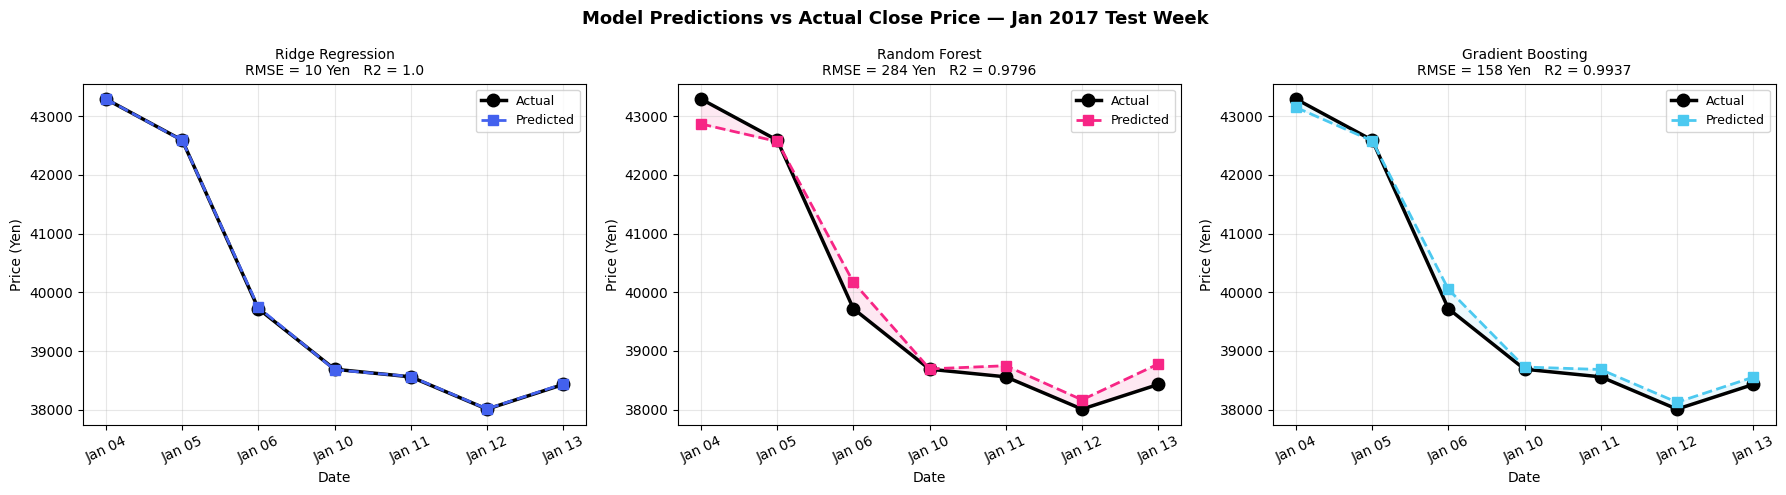

The closer the dashed line is to the solid line, the better the model.


In [29]:
# Chart 1: Predicted vs Actual
COLORS = ['#4361EE', '#F72585', '#4CC9F0']
test_labels = test_fe['Date'].dt.strftime('%b %d').tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Model Predictions vs Actual Close Price — Jan 2017 Test Week',
             fontsize=13, fontweight='bold')

for i, (name, pred) in enumerate(preds.items()):
    ax = axes[i]
    ax.plot(test_labels, y_test.values, 'o-',  color='black',   lw=2.5, ms=9, label='Actual')
    ax.plot(test_labels, pred,          's--', color=COLORS[i], lw=2.0, ms=7, label='Predicted')
    ax.fill_between(test_labels, y_test.values, pred, alpha=0.1, color=COLORS[i])

    r2   = results[name]['R2']
    rmse = results[name]['RMSE (Yen)']
    ax.set_title(name + '\nRMSE = ' + str(int(rmse)) + ' Yen   R2 = ' + str(r2), fontsize=10)
    ax.set_xlabel('Date')
    ax.set_ylabel('Price (Yen)')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.show()
print('The closer the dashed line is to the solid line, the better the model.')

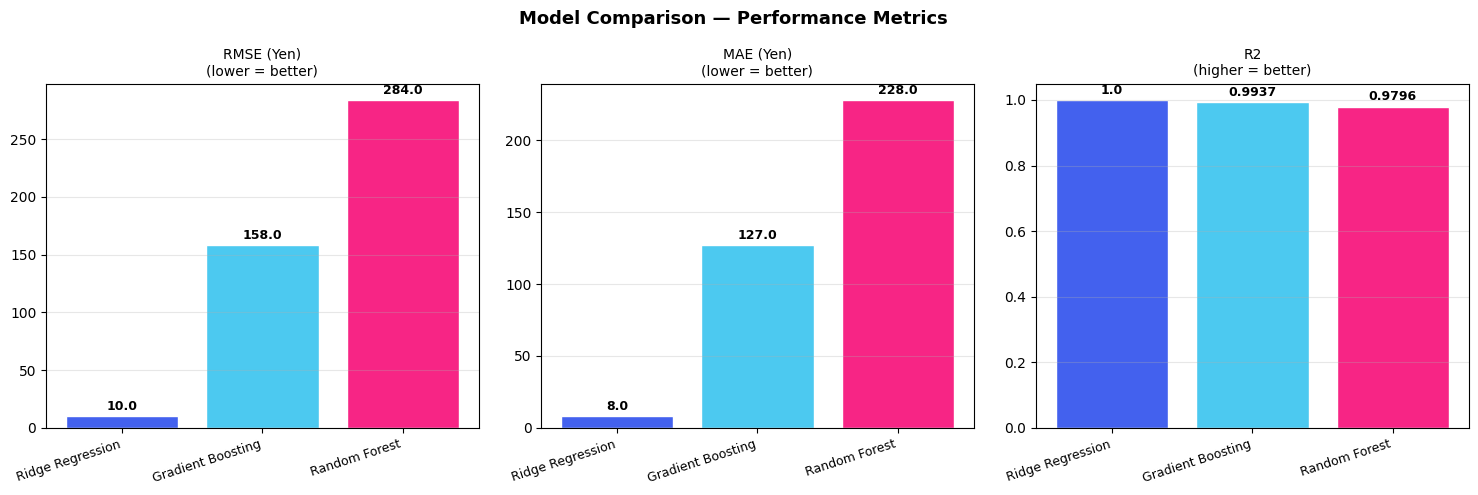

In [30]:
# Chart 2: Metric Comparison Bars
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — Performance Metrics', fontsize=13, fontweight='bold')

names      = list(results_df.index)
bar_colors = [COLORS[list(models.keys()).index(n)] for n in names]

for ax, (metric, label, note) in zip(axes, [
    ('RMSE (Yen)', 'RMSE (Yen)', 'lower = better'),
    ('MAE (Yen)',  'MAE (Yen)',  'lower = better'),
    ('R2',         'R2',         'higher = better'),
]):
    vals = results_df[metric].values
    bars = ax.bar(names, vals, color=bar_colors, edgecolor='white', linewidth=1)
    ax.set_title(label + '\n(' + note + ')', fontsize=10)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=18, ha='right', fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                str(round(v, 1)) if metric != 'R2' else str(round(v, 4)),
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

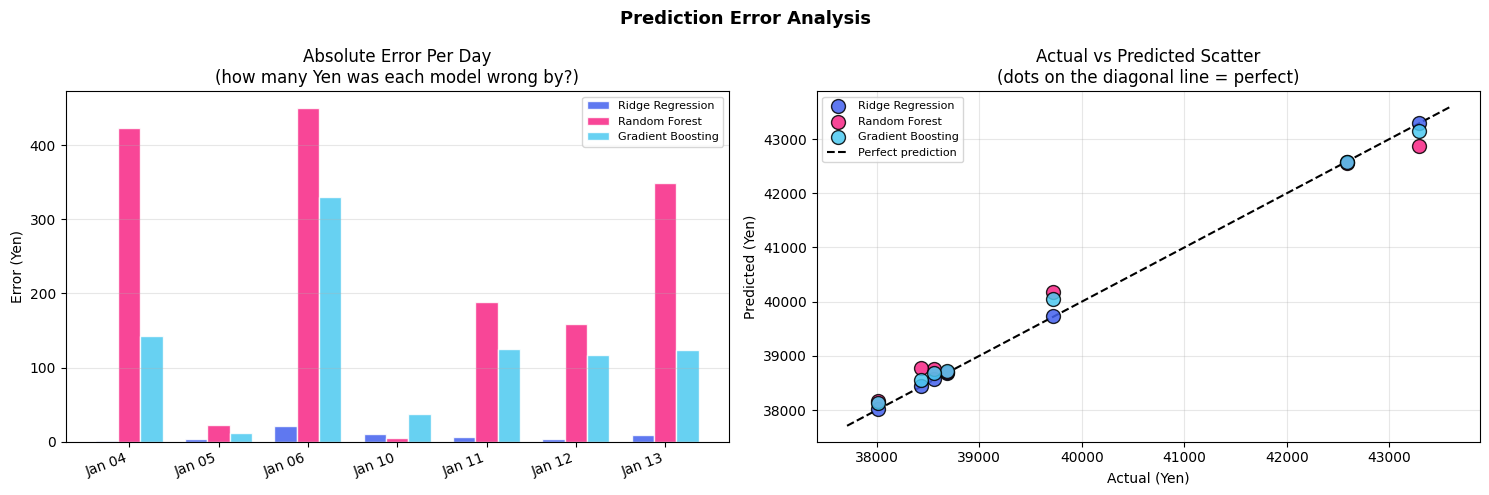

Left: shorter bars = more accurate that day.
Right: dots closer to the diagonal dashed line = more accurate overall.


In [31]:
# Chart 3: Error Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Prediction Error Analysis', fontsize=13, fontweight='bold')

# Left: absolute error per day
ax = axes[0]
x = np.arange(len(test_labels))
w = 0.25
for i, (name, pred) in enumerate(preds.items()):
    abs_err = np.abs(y_test.values - pred)
    ax.bar(x + i * w, abs_err, width=w, color=COLORS[i], label=name, alpha=0.85, edgecolor='white')
ax.set_xticks(x + w)
ax.set_xticklabels(test_labels, rotation=20, ha='right')
ax.set_title('Absolute Error Per Day\n(how many Yen was each model wrong by?)')
ax.set_ylabel('Error (Yen)')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Right: actual vs predicted scatter
ax = axes[1]
for i, (name, pred) in enumerate(preds.items()):
    ax.scatter(y_test.values, pred, color=COLORS[i], s=100, label=name,
               edgecolors='black', zorder=3, alpha=0.85)
mn = min(y_test.min(), min(p.min() for p in preds.values())) - 300
mx = max(y_test.max(), max(p.max() for p in preds.values())) + 300
ax.plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect prediction')
ax.set_title('Actual vs Predicted Scatter\n(dots on the diagonal line = perfect)')
ax.set_xlabel('Actual (Yen)')
ax.set_ylabel('Predicted (Yen)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('Left: shorter bars = more accurate that day.')
print('Right: dots closer to the diagonal dashed line = more accurate overall.')

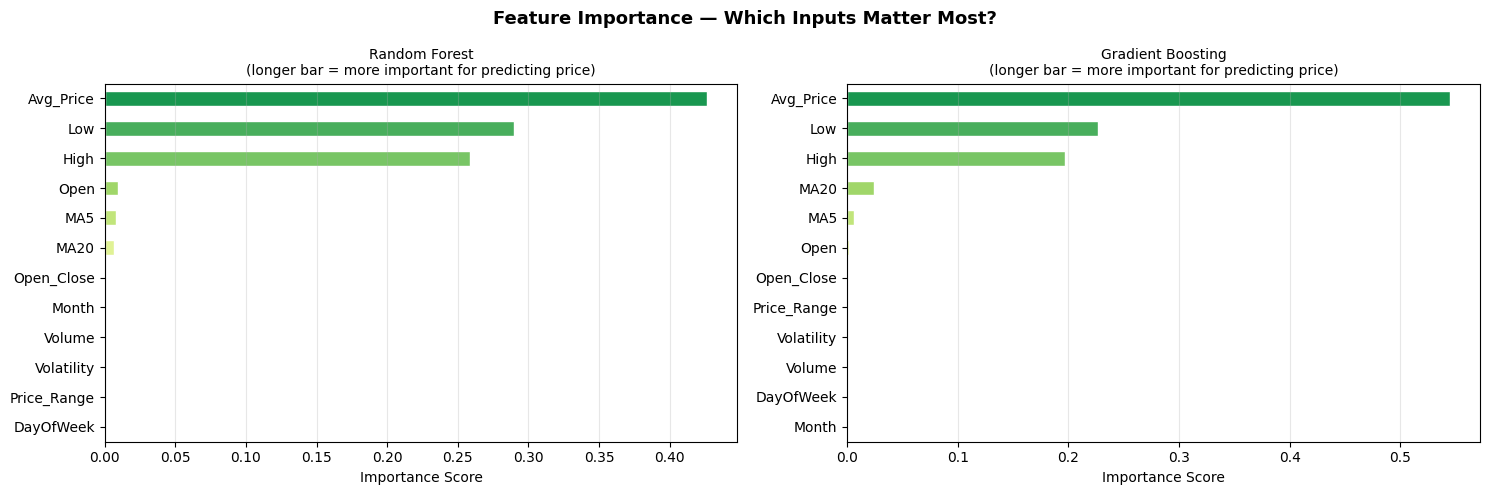

High, Low, Avg_Price, and MA5/MA20 typically rank highest.
This makes sense — today price closely follows recent prices and intraday range.


In [32]:
# Chart 4: Feature Importance
# Only tree-based models have feature_importances_
# It tells us: which input features were most useful for predicting price?

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Feature Importance — Which Inputs Matter Most?', fontsize=13, fontweight='bold')

for ax, (name, model) in zip(axes, [('Random Forest', best_rf), ('Gradient Boosting', best_gb)]):
    imp = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(imp)))
    imp.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    ax.set_title(name + '\n(longer bar = more important for predicting price)', fontsize=10)
    ax.set_xlabel('Importance Score')
    ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print('High, Low, Avg_Price, and MA5/MA20 typically rank highest.')
print('This makes sense — today price closely follows recent prices and intraday range.')

---
## Step 7 — Summary and Final Verdict

In [33]:
winner      = results_df['RMSE (Yen)'].idxmin()
winner_rmse = results_df.loc[winner, 'RMSE (Yen)']
winner_r2   = results_df.loc[winner, 'R2']
winner_mape = results_df.loc[winner, 'MAPE (%)']

print('=' * 60)
print('  COMPLETE RESULTS SUMMARY')
print('=' * 60)
display(results_df)

print()
print('WINNER:', winner)
print('-' * 50)
print('  Average error (RMSE) :', round(winner_rmse, 0), 'Yen')
print('  Accuracy (R2)        :', winner_r2, '(', round(winner_r2 * 100, 1), '% of variance explained)')
print('  Average % error      :', winner_mape, '%')
print()
print('KEY THINGS YOU LEARNED:')
print('-' * 50)
print('  EDA              -> Always explore your data first!')
print('  No missing values -> No cleaning needed in this dataset.')
print('  Feature Engineering -> New columns helped the models.')
print('  Scaling          -> Essential so all features are on the same scale.')
print('  Grid Search      -> Automatically finds the best settings.')
print('  Cross-Validation -> Fairer than a single train/test split.')
print('  RMSE / MAE / R2  -> Different ways to measure accuracy.')
print()
print('NOTE: The test set is only 7 days.')
print('A larger test set would give more reliable metric scores.')
print('In real trading, past performance does not guarantee future results.')

  COMPLETE RESULTS SUMMARY


,RMSE (Yen),MAE (Yen),R2,MAPE (%),CV-RMSE
Ridge Regression,10.0,8.0,1.0000,0.02,15.0
Gradient Boosting,158.0,127.0,0.9937,0.32,2234.0
Random Forest,284.0,228.0,0.9796,0.57,2320.0



WINNER: Ridge Regression
--------------------------------------------------
  Average error (RMSE) : 10.0 Yen
  Accuracy (R2)        : 1.0 ( 100.0 % of variance explained)
  Average % error      : 0.02 %

KEY THINGS YOU LEARNED:
--------------------------------------------------
  EDA              -> Always explore your data first!
  No missing values -> No cleaning needed in this dataset.
  Feature Engineering -> New columns helped the models.
  Scaling          -> Essential so all features are on the same scale.
  Grid Search      -> Automatically finds the best settings.
  Cross-Validation -> Fairer than a single train/test split.
  RMSE / MAE / R2  -> Different ways to measure accuracy.

NOTE: The test set is only 7 days.
A larger test set would give more reliable metric scores.
In real trading, past performance does not guarantee future results.


---
## What to Try Next (Bonus Challenges)

Once you are comfortable with this notebook, try these:

1. **Add more features** — try MA50 (50-day moving average) or RSI (Relative Strength Index)
2. **Try more models** — SVR (Support Vector Regression) or XGBoost
3. **Expand the test set** — use 1 month instead of 1 week
4. **Plot the learning curve** — does accuracy improve with more training data?
5. **Try a different stock** — download data from Yahoo Finance and repeat!

```python
# Bonus: download stock data with one line
# !pip install yfinance
# import yfinance as yf
# df = yf.download('9983.T', start='2012-01-01', end='2017-01-31')
# 9983.T = Fast Retailing on the Tokyo Stock Exchange
```

---
Well done for completing this notebook!